# EDA - Commercial Auto Insurance Risk Scoring

Exploration of train.csv and score.csv before building the model. The goal is to answer a few questions that affect how the model
should be built and validated (is the target balanced, are there columns we shouldn't be using, are the categories clean, and does the same insured show up more than once.)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",50)
sns.set_theme(style="whitegrid")

In [ ]:
train=pd.read_csv("train.csv")
score=pd.read_csv("score.csv")
print("train:",train.shape)
print("score:",score.shape)
print("Columns in train but not score:",sorted(set(train.columns)-set(score.columns)))
print("Columns in score but not train:",sorted(set(score.columns)-set(train.columns)))

train: (15075, 31)
score: (3000, 28)
Columns in train but not score: ['claim_count', 'has_safety_program', 'total_loss_amount']
Columns in score but not train: []


train.csv contains the outcome variables claim_count and total_loss_amount, as well as the train-only variable has_safety_program, while score.csv contains neither of these columns and has no additional columns that are not in train.csv.

## Target: did the policy have a claim?

Positive rate (had >=1 claim): 0.1234
claim_count
0    13214
1     1623
2      208
3       25
4        3
5        1
7        1
Name: count, dtype: int64


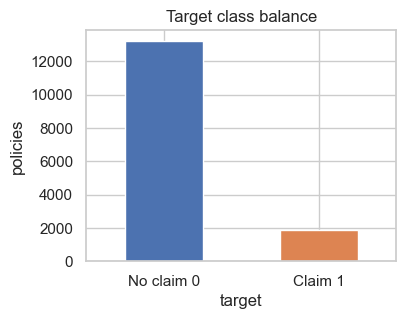

In [95]:
train["target"]=(train["claim_count"]>0).astype(int)
print("Positive rate (had >=1 claim):",round(train["target"].mean(), 4))
print(train["claim_count"].value_counts().sort_index())

fig, ax=plt.subplots(figsize=(4,3))
train["target"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452",])
ax.set_xticklabels(["No claim 0", "Claim 1",], rotation=0)
ax.set_title("Target class balance")
ax.set_ylabel("policies")
plt.show()

About 12% of policies had at least one claim. Most of those had one. 

How big are the losses when a claim does happen?

count    1.861000e+03
mean     7.834614e+04
std      2.502765e+05
min      3.983700e+02
25%      3.640700e+03
50%      9.554980e+03
75%      5.094360e+04
max      5.871552e+06
Name: total_loss_amount, dtype: float64


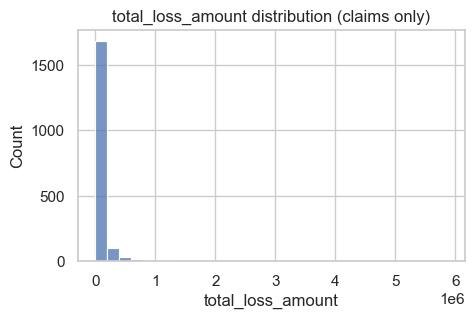

In [78]:
claims=train.loc[train.target==1,"total_loss_amount"]
print(claims.describe())
fig, ax=plt.subplots(figsize=(5,3))
sns.histplot(claims, bins=30,ax=ax)
ax.set_title("total_loss_amount distribution (claims only)")
plt.show()

The loss data is quite skewed, with a few large claims pulling the average up. Because of this, it makes more sense to predict whether a claim happens rather than the exact claim amount.

## Columns that shouldn't be used as features

The data dictionary says four columns are only known after a claim is resolved
(first_claim_reported_date, claim_paid_amount_current_period, claim_status_current_period, days_to_first_claim_report).

In [79]:
problem_columns=["first_claim_reported_date", "claim_paid_amount_current_period","claim_status_current_period", "days_to_first_claim_report"]
miss_train=train[problem_columns].isna().mean().rename("missing_share_train")
miss_score=score[problem_columns].isna().mean().rename("missing_share_score")
print(pd.concat([miss_train, miss_score], axis=1))
for c in problem_columns:
    n=score[c].notna().sum()
    print(f"{c:38s} non-null in score.csv: {n} / {len(score)} rows")

                                  missing_share_train  missing_share_score
first_claim_reported_date                    0.876551                  0.9
claim_paid_amount_current_period             0.000000                  0.9
claim_status_current_period                  0.000000                  0.9
days_to_first_claim_report                   0.876551                  0.9
first_claim_reported_date              non-null in score.csv: 300 / 3000 rows
claim_paid_amount_current_period       non-null in score.csv: 300 / 3000 rows
claim_status_current_period            non-null in score.csv: 300 / 3000 rows
days_to_first_claim_report             non-null in score.csv: 300 / 3000 rows


These are fully missing in train.csv for policies with no claim, and filled in when there is
one, using them as predictors would basically be leaking the answer.

score.csv is supposed to have no outcome info for this period, but these
columns aren't empty.

## Categorical columns

In [80]:
categorical_columns=["coverage_type","business_type","state","payment_frequency","claim_status_current_period"]
for col in categorical_columns:
    train_values= set(train[col].dropna().astype(str).str.strip().unique())
    score_values= set(score[col].dropna().astype(str).str.strip().unique())
    unseen=score_values-train_values
    print("=" * 60)
    print(f"Column: {col}")
    print("TRAIN categories:", sorted(train_values))
    print("SCORE categories:", sorted(score_values))
    print("Unseen categories in SCORE:", unseen)
    

Column: coverage_type
TRAIN categories: ['AL', 'APD']
SCORE categories: ['AL', 'APD']
Unseen categories in SCORE: set()
Column: business_type
TRAIN categories: ['Agriculture', 'CONSTRUCTION', 'Construction', 'OTHER', 'Other', 'RETAIL', 'Retail', 'SERVICE', 'Service', 'TRUCKING', 'Trucking', 'construction', 'other', 'retail', 'service', 'trucking']
SCORE categories: ['CONSTRUCTION', 'Construction', 'OTHER', 'Other', 'RETAIL', 'RIDESHARE', 'Retail', 'Rideshare', 'SERVICE', 'Service', 'TRUCKING', 'Trucking', 'construction', 'other', 'retail', 'rideshare', 'service', 'trucking']
Unseen categories in SCORE: {'Rideshare', 'rideshare', 'RIDESHARE'}
Column: state
TRAIN categories: ['AZ', 'CA', 'CO', 'FL', 'GA', 'IL', 'NC', 'NY', 'OH', 'PA', 'TX', 'WA']
SCORE categories: ['AZ', 'CA', 'CO', 'FL', 'GA', 'IL', 'NC', 'NY', 'OH', 'PA', 'TX', 'WA']
Unseen categories in SCORE: set()
Column: payment_frequency
TRAIN categories: ['Annual', 'Monthly', 'Quarterly']
SCORE categories: ['Annual', 'Monthly', '

business_type has the same categories written with different casing (CONSTRUCTION, Construction,..), so I cleaned them before encoing (load_and_prepare function).

score.csv contains Rideshare business type, which is not in train.csv.

In [96]:
train["business_type"].value_counts()

business_type
Trucking        3367
Retail          2799
Construction    2285
Service         2278
trucking         696
retail           596
Other            573
TRUCKING         473
construction     435
service          431
RETAIL           387
SERVICE          286
CONSTRUCTION     286
other            100
OTHER             75
Agriculture        8
Name: count, dtype: int64

Agriculutre was not mentioned in the data_dictionary and appears in only 8 rows. Therefore, I decided to group it into the Other category to avoid overfitting.

## insured_id - same company can appear more than once

1     282
2     572
3     743
4     706
5     573
6     392
7     230
8     120
9      47
10     23
11     12
12      2
Name: count, dtype: int64


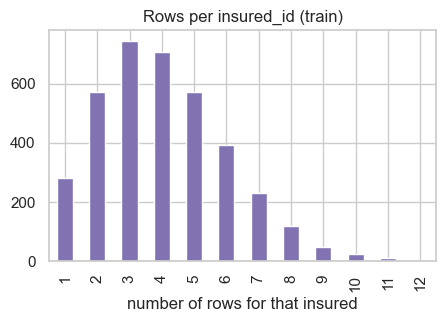

In [81]:
rows_per_insured=train.groupby("insured_id").size()
print(rows_per_insured.value_counts().sort_index())
fig, ax= plt.subplots(figsize=(5,3))
rows_per_insured.value_counts().sort_index().plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Rows per insured_id (train)")
ax.set_xlabel("number of rows for that insured")
plt.show()


Most insureds have multiple rows, because company can have different policies or appear again in another year. Important for cross-validation.

Do the same companies show up in both train and score?

In [82]:
overlap=set(train.insured_id)&set(score.insured_id)
print(f"insured_id in train and score: {len(overlap)} companies")
print(f"% of score rows that are repeat customers: {score['insured_id'].isin(train.insured_id).mean():.2%}")

insured_id in train and score: 733 companies
% of score rows that are repeat customers: 99.27%


There is a lot of overlap, with most of score.csv being existing customers. Because of this, I checked model performance separately for existing and new customers.

## Numeric features - distributions

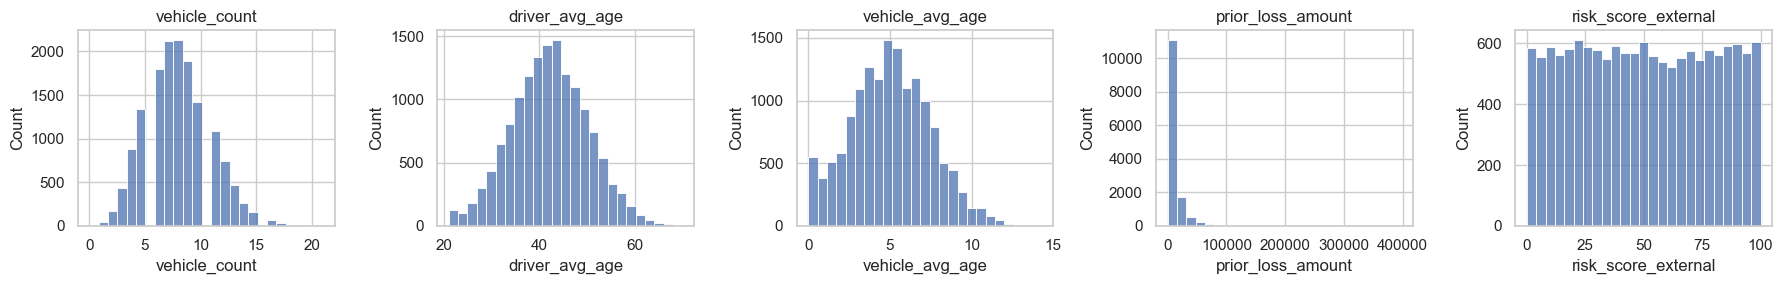

In [83]:
num_columns=["vehicle_count", "driver_avg_age", "vehicle_avg_age","prior_loss_amount", "risk_score_external"]
fig, axes= plt.subplots(1, 5, figsize=(18,3))
for ax, col in zip(axes, num_columns):
    sns.histplot(train[col].dropna(), bins=25, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

The distributions look normal, with no major unusual patterns in fleet size, driver age, or vehicle age.

## Does claim rate actually move with these features?

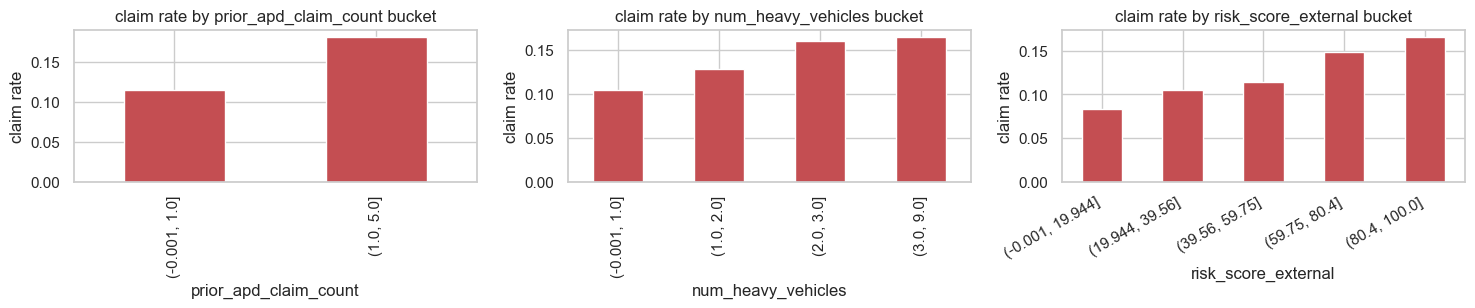

In [84]:
def claim_rate_by_bucket(df, col, q=5):
    b=pd.qcut(df[col], q=q, duplicates="drop")
    return df.groupby(b,observed=True)["target"].mean()
fig, axes=plt.subplots(1,3,figsize=(15,3.5))
for ax,col in zip(axes,["prior_apd_claim_count","num_heavy_vehicles","risk_score_external"]):
    try:
        rates=claim_rate_by_bucket(train, col)
    except ValueError:
        rates= train.groupby(col)["target"].mean()
    rates.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"claim rate by {col} bucket")
    ax.set_ylabel("claim rate")
plt.tight_layout()
plt.xticks(rotation=30, ha="right")
plt.show()        

prior_apd_claim_count, num_heavy_vehicles, and risk_score_external show increase in claim rate, they are useful for the model.

## Correlation between numeric features and target

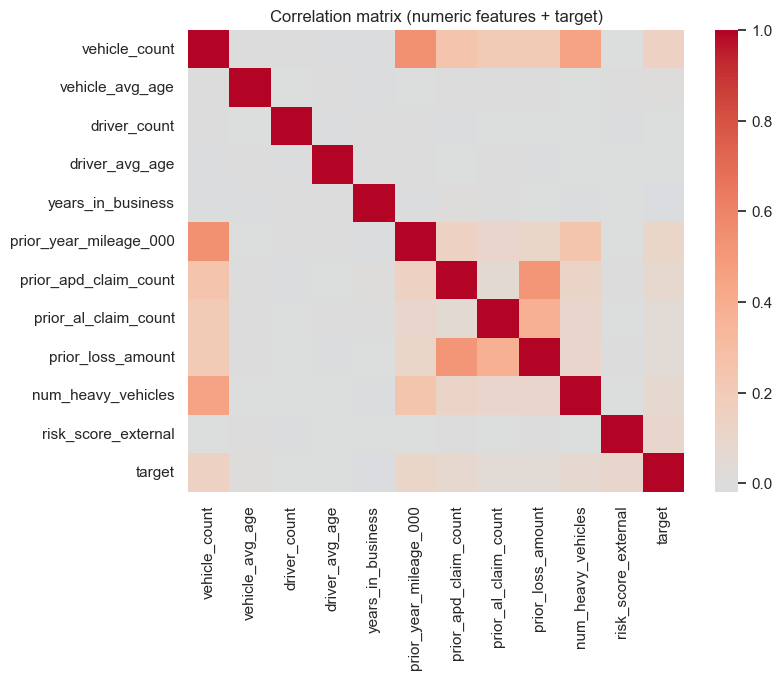

In [85]:
num_for_corr= ["vehicle_count","vehicle_avg_age","driver_count","driver_avg_age","years_in_business","prior_year_mileage_000","prior_apd_claim_count","prior_al_claim_count","prior_loss_amount","num_heavy_vehicles","risk_score_external","target"]
corr= train[num_for_corr].corr()
fig, ax= plt.subplots(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation matrix (numeric features + target)")
plt.show()

No single feature has a strong correlation with the target, and there are no obvious multicollinearity issues. Claim risk is likely influenced by a combination of factors rather than one variable alone.

## Does APD vs AL matter?

coverage_type
AL     0.090752
APD    0.156142
Name: target, dtype: float64
                         APD     AL
prior_apd_claim_count  0.102  0.045
prior_al_claim_count   0.024  0.067
num_heavy_vehicles     0.065  0.079
risk_score_external    0.099  0.083
driver_avg_age        -0.008  0.005
vehicle_avg_age        0.021 -0.003


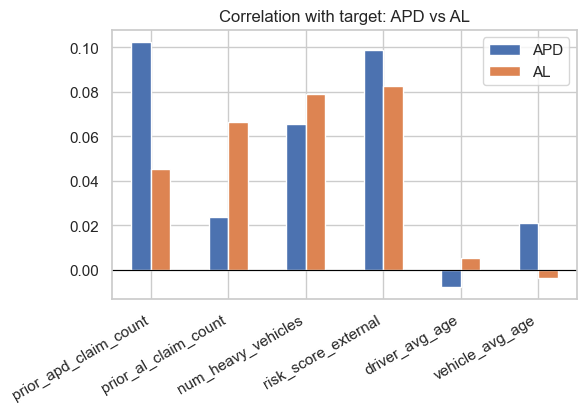

In [86]:
print(train.groupby("coverage_type")["target"].mean())
compare_feats= ["prior_apd_claim_count","prior_al_claim_count","num_heavy_vehicles",
                  "risk_score_external","driver_avg_age","vehicle_avg_age"]
corr_by_cov = {}
for cov in ["APD","AL"]:
    sub= train[train.coverage_type== cov]
    corr_by_cov[cov]= sub[compare_feats + ["target"]].corr()["target"].drop("target")
comp= pd.DataFrame(corr_by_cov)
print(comp.round(3))

fig, ax= plt.subplots(figsize=(6,3.5))
comp.plot(kind="bar", ax=ax)
ax.set_title("Correlation with target: APD vs AL")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.show()


The overall claim rate is similar for APD and AL, but some features behave differently. For example, prior APD claims seem to be more relevant for predicting future APD claims. In my opinion the differences are not large enough to justify separate models.